# Market regime detection: MES + MNQ, daily bars, full history

Exploratory notebook, not a strategy backtest (same spirit as
`notebooks/pipelines/cointegration/mes_mnq_m2k_cointegration.ipynb`). Goal:
classify each day into a market regime -- trending vs. choppy, crossed with
calm vs. volatile -- and visualize it directly on the price chart, as a first
step toward regime-conditional strategy selection (e.g. this repo's
Bollinger mean-reversion sleeve profiting through a violent selloff, when a
trend-following sleeve would have been fighting it).

**Two independent axes, kept simple and inspectable rather than starting
with an opaque model:**

1. **Trend strength** -- `Indicators.adx` (already in this codebase).
   ADX >= 25 -> "Trending", ADX < 25 -> "Choppy". Direction-agnostic: says
   *how strongly* price is moving in one direction, not which direction.
2. **Volatility level** -- 20-day realized volatility (annualized), ranked
   as a percentile against its own trailing 252-day (1-year) window rather
   than a fixed absolute threshold, so it adapts across the dataset's very
   different volatility eras (2019 calm bull vs. 2020 COVID crash vs. 2022
   rate-hike bear market). >= 50th percentile -> "High-Vol", else "Low-Vol".

Crossed, these give four regimes: **Trending/Low-Vol** (calm trend -- classic
breakout conditions), **Trending/High-Vol** (violent trend -- e.g. a crash),
**Choppy/Low-Vol** (quiet range -- classic mean-reversion conditions),
**Choppy/High-Vol** (violent whipsaw -- dangerous for both mechanisms). A
200-day EMA is overlaid for directional (bull/bear) context, kept separate
from the regime coloring rather than folding into an 8-way combinatorial
label.

Daily bars (not hourly): cleaner for a full-history-on-one-chart
visualization over ~7 years without overplotting -- the regime axes
themselves (trend strength, realized vol) are also naturally daily-scale
concepts, not intrabar ones.


In [1]:
import os
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from backtester.indicators import Indicators
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/regime_detection


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))

ohlc_mes = load_1m_parquet_resampled(mes_path, interval=1, unit_of_time="day")
ohlc_mnq = load_1m_parquet_resampled(mnq_path, interval=1, unit_of_time="day")
print(f"MES bars: {len(ohlc_mes)}  span: {ohlc_mes.index[0].date()} -> {ohlc_mes.index[-1].date()}")
print(f"MNQ bars: {len(ohlc_mnq)}  span: {ohlc_mnq.index[0].date()} -> {ohlc_mnq.index[-1].date()}")


MES bars: 2240  span: 2019-05-05 -> 2026-07-12
MNQ bars: 2241  span: 2019-05-05 -> 2026-07-13


## Computing the regime label

`ADX_LENGTH=14` (standard), `VOL_LOOKBACK=20` trading days for realized
volatility, `VOL_PERCENTILE_WINDOW=252` trading days (~1 year) for the
adaptive percentile rank.


In [3]:
ADX_LENGTH = 14
VOL_LOOKBACK = 20
VOL_PERCENTILE_WINDOW = 252
TREND_MA_LENGTH = 200


def compute_regime(ohlc: pd.DataFrame) -> pd.DataFrame:
    '''Returns a copy of ohlc with adx, vol_percentile, trend_ma, and a combined
    regime label column added.'''
    df = ohlc.copy()

    df["adx"] = Indicators.adx(df, length=ADX_LENGTH)
    df["is_trending"] = df["adx"] >= 25

    log_returns = np.log(df["close"] / df["close"].shift(1))
    df["realized_vol"] = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    df["vol_percentile"] = df["realized_vol"].rolling(
        VOL_PERCENTILE_WINDOW, min_periods=60
    ).rank(pct=True)
    df["is_high_vol"] = df["vol_percentile"] >= 0.5

    df["trend_ma"] = Indicators.ema(df, length=TREND_MA_LENGTH)
    df["is_bull_bias"] = df["close"] >= df["trend_ma"]

    conditions = [
        df["is_trending"] & ~df["is_high_vol"],
        df["is_trending"] & df["is_high_vol"],
        ~df["is_trending"] & ~df["is_high_vol"],
        ~df["is_trending"] & df["is_high_vol"],
    ]
    labels = ["Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"]
    df["regime"] = np.select(conditions, labels, default="Unclassified")
    df.loc[df["regime"] == "Unclassified", "regime"] = np.nan

    return df


regime_mes = compute_regime(ohlc_mes)
regime_mnq = compute_regime(ohlc_mnq)

for name, df in [("MES", regime_mes), ("MNQ", regime_mnq)]:
    valid = df.dropna(subset=["regime"])
    print(f"{name}: {len(valid)} labeled days ({len(df) - len(valid)} warmup days unlabeled)")
    print((valid["regime"].value_counts(normalize=True) * 100).round(1).to_string())
    print()


MES: 2240 labeled days (0 warmup days unlabeled)
regime
Choppy / Low-Vol       34.6
Choppy / High-Vol      27.8
Trending / High-Vol    19.9
Trending / Low-Vol     17.7

MNQ: 2241 labeled days (0 warmup days unlabeled)
regime
Choppy / Low-Vol       35.4
Choppy / High-Vol      29.0
Trending / High-Vol    20.9
Trending / Low-Vol     14.6



## Regime-labeled price chart

Background shading = regime (four colors), overlaid with the close price
and its 200-day EMA (directional context, kept separate from the regime
coloring itself).


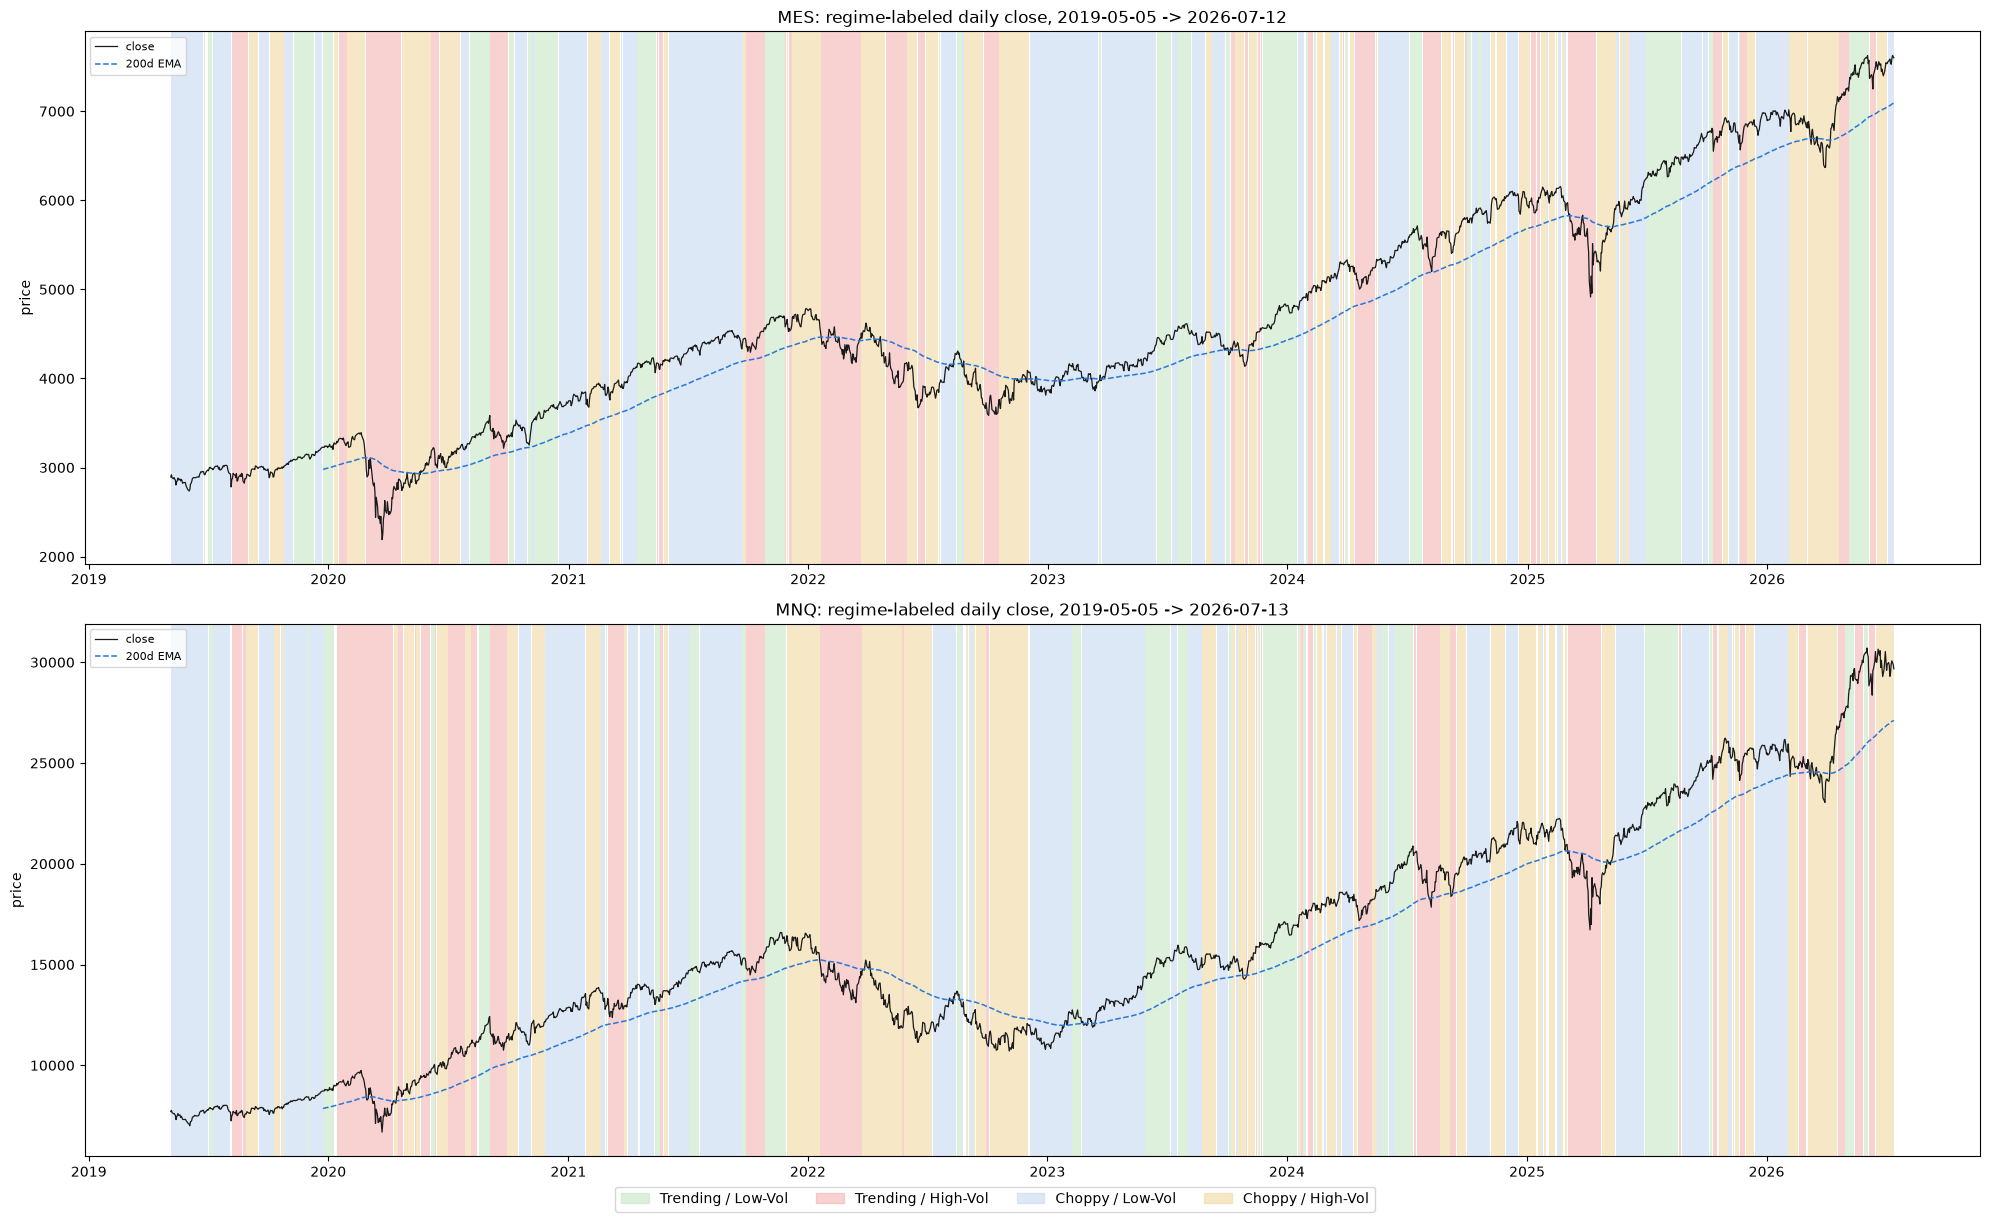

In [4]:
REGIME_COLORS = {
    "Trending / Low-Vol": "#c6e6c6",
    "Trending / High-Vol": "#f4b3b3",
    "Choppy / Low-Vol": "#c6d9f0",
    "Choppy / High-Vol": "#f0d9a3",
}


def _regime_spans(df: pd.DataFrame) -> list[tuple[pd.Timestamp, pd.Timestamp, str]]:
    '''Collapses the per-day regime column into contiguous (start, end, label)
    spans, so plotting uses one axvspan per regime run instead of one per day.'''
    valid = df.dropna(subset=["regime"])
    if valid.empty:
        return []
    spans = []
    span_start = valid.index[0]
    current_label = valid["regime"].iloc[0]
    prev_ts = span_start
    for ts, label in valid["regime"].items():
        if label != current_label:
            spans.append((span_start, prev_ts, current_label))
            span_start = ts
            current_label = label
        prev_ts = ts
    spans.append((span_start, prev_ts, current_label))
    return spans


def plot_regime_chart(df: pd.DataFrame, display_symbol: str, ax) -> None:
    for start, end, label in _regime_spans(df):
        ax.axvspan(start, end, color=REGIME_COLORS[label], alpha=0.6, linewidth=0)

    ax.plot(df.index, df["close"], color="#1a1a1a", linewidth=0.9, label="close")
    ax.plot(df.index, df["trend_ma"], color="#2a78d6", linewidth=1.1, linestyle="--",
             label=f"{TREND_MA_LENGTH}d EMA")
    ax.set_title(f"{display_symbol}: regime-labeled daily close, {df.index[0].date()} -> {df.index[-1].date()}")
    ax.set_ylabel("price")
    ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


fig, axes = plt.subplots(2, 1, figsize=(20, 12))
plot_regime_chart(regime_mes, "MES", axes[0])
plot_regime_chart(regime_mnq, "MNQ", axes[1])

legend_patches = [mpatches.Patch(color=c, alpha=0.6, label=l) for l, c in REGIME_COLORS.items()]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
plt.show()


## Sanity check: does the classification match known real-world regimes?

The 2020 COVID crash (~2020-02-20 to 2020-04-07) and the 2022 rate-hike bear
market (~2022-01-01 to 2022-10-15) are both well-known violent-selloff
periods -- checking what this notebook's own classification says about them
is a direct test of whether the regime labels are actually picking up
something real, not just producing plausible-looking noise.


In [5]:
KNOWN_PERIODS = {
    "2020 COVID crash": ("2020-02-20", "2020-04-07"),
    "2022 rate-hike bear market": ("2022-01-01", "2022-10-15"),
}

for name, df in [("MES", regime_mes), ("MNQ", regime_mnq)]:
    print(f"=== {name} ===")
    for period_name, (start, end) in KNOWN_PERIODS.items():
        window = df.loc[start:end].dropna(subset=["regime"])
        if window.empty:
            print(f"  {period_name}: no data in range")
            continue
        counts = (window["regime"].value_counts(normalize=True) * 100).round(1)
        bull_pct = (window["is_bull_bias"].mean() * 100).round(1)
        print(f"  {period_name} ({len(window)} days, {bull_pct}% bull-bias days):")
        for label, pct in counts.items():
            print(f"    {label}: {pct}%")
    print()


=== MES ===
  2020 COVID crash (41 days, 14.6% bull-bias days):
    Trending / High-Vol: 87.8%
    Choppy / High-Vol: 12.2%
  2022 rate-hike bear market (245 days, 23.7% bull-bias days):
    Trending / High-Vol: 44.1%
    Choppy / High-Vol: 42.9%
    Choppy / Low-Vol: 10.2%
    Trending / Low-Vol: 2.9%

=== MNQ ===
  2020 COVID crash (41 days, 26.8% bull-bias days):
    Trending / High-Vol: 100.0%
  2022 rate-hike bear market (245 days, 12.7% bull-bias days):
    Choppy / High-Vol: 54.7%
    Trending / High-Vol: 25.3%
    Choppy / Low-Vol: 17.6%
    Trending / Low-Vol: 2.4%



## Findings

**The classification captures something real -- it cleanly distinguishes
two very different bear markets rather than just labeling both as similar.**

**Overall regime distribution** (both symbols agree closely): Choppy/Low-Vol
is the most common regime (~35%), Choppy/High-Vol second (~28-29%),
Trending/High-Vol third (~20-21%), Trending/Low-Vol rarest (~15-18%). Calm
trends (the easiest, most comfortable regime to trade) are the least common
state in this dataset -- most of the time this market is either quietly
range-bound or actively volatile in some way.

**The sanity check is the interesting part.** The 2020 COVID crash and the
2022 rate-hike bear market are both "the market went down a lot," but this
classification tells them apart correctly:

| period | MES dominant regime | MNQ dominant regime |
|---|---|---|
| 2020 COVID crash | Trending/High-Vol (87.8%) | Trending/High-Vol (100%) |
| 2022 rate-hike bear | split: 44.1% Trending/High-Vol, 42.9% Choppy/High-Vol | Choppy/High-Vol dominant (54.7%) |

**2020 was a clean, fast, one-directional crash** -- almost entirely
Trending/High-Vol on both symbols, matching the real-world V-shaped
character of that selloff. **2022 was a grinding, whipsaw bear market** --
much more evenly split between Trending and Choppy on MES, and *majority
Choppy* on MNQ -- matching 2022's well-known character as a volatile market
with repeated sharp bear-market rallies rather than a single clean move.

**This directly speaks to the original question**: a trend-following sleeve
should have done relatively well in the 2020 crash (a strong, sustained
directional move, even if the direction was down and these strategies are
long-only) but likely struggled through 2022's Choppy/High-Vol grind, which
is closer to the natural habitat of a mean-reversion strategy like Bollinger
MR (short-term overextensions repeatedly reverting, even inside a larger
downtrend). This is consistent with -- though not yet formally tested
against -- the observation that motivated this notebook.

**Natural next step (not done here)**: score each of this program's
confirmed strategies (Bollinger MR, Donchian, SuperTrend) by regime --
does trade-level Sharpe actually differ across these four labels the way
this reasoning predicts? That would turn this from a descriptive
visualization into an actual regime-conditional sleeve-selection signal for
the combination portfolio -- the concrete win condition the user originally
asked about.